# Generate a simulation of an observation (a "pseudo-observation")

In [3]:
import os
import pickle
import sqlite3
import sys

import numpy as np
import pandas as pd
import afterglowpy as grb
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta

In [5]:
sys.path.append('/home/masson/afterglowpy/orphan_modules')
from tools import time_coord
from grb_interface import make_grb_spectrum

sys.path.append('/home/masson/rubin_sim')
import rubin_sim.photUtils.PhotometricParameters as PhotometricParameters
from rubin_sim.data import get_baseline
from rubin_sim.photUtils.Bandpass import Bandpass
from rubin_sim.photUtils.Sed import Sed
from rubin_sim.photUtils import calcMagError_m5

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## Define some functions

In [13]:
def compute_mags(i, wls, fnus, obs_t, f, lsst):
    """ Compute magnitudes
    """
    
    new_grb_sed = Sed()
    new_grb_sed.wavelen = np.array(wls)
    new_grb_sed.fnu = np.array(fnus)
    # convert fnu to flambda
    new_grb_sed.fnuToflambda()
    # Calculate expected AB magnitudes. 
    new_grb_mags = {}
    new_grb_mags[str(f)] = new_grb_sed.calcMag(lsst[f])
    # time is one column
    new_grb_mags['obs_time'] = obs_t
    # Make a dataframe just to get a nice output cell.
    return pd.DataFrame(new_grb_mags, index=[i])


def grb_obs_duration(df_sky, grb_time):
    """ Compute the observation time in the GRB time frame, i.e. from GRB T_0
    """

    obs_times_grb_frame = df_sky['observationStartMJD'] - grb_time.mjd
    time_bins = obs_times_grb_frame[obs_times_grb_frame > 0]
    return time_bins
    # time_bins.to_dict()
    

def df_obs(P, df_sky, time_bins, lsst):
    """ Compute magnitudes in each filter at the observation time
    """
    
    Fnu_Jy = dict()
    for obs_id, obs_t in time_bins.to_dict().items():
        wl_full_band, freq_full_band, t, Fnu_Jy[obs_id] = make_grb_spectrum(E0=P['E0'],
                                                                            z=P['z'], n0=P['n0'],
                                                                            thetaObs=P['thetaObs'],
                                                                            thetaWing=P['thetaWing'],
                                                                            thetaCore=P['thetaCore'],
                                                                            t=obs_t * grb.day2sec)

    obs_list = list()
    for obs_id, fnu_val in Fnu_Jy.items():
        obs_t = time_bins[obs_id]
        filt = df_sky[df_sky['observationId']==obs_id]['filter']
        df = compute_mags(obs_id, wl_full_band, fnu_val, obs_t, filt.values[0], lsst)
        obs_list.append(df)
        
    return obs_list


def real_obs(obs_df, df_sky, time_bins, grb_time, lsst):
    """ Keep only "real" observations for the right filter
    """

    filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'y': 'm'}
    x_times = []
    y_mags = []
    z_colors = []
    mags_lim = []
    mags_err = []

    for obs_id, obs in obs_df.iterrows():

        filt = df_sky[df_sky['observationId'] == obs_id]['filter']
        lim = df_sky[df_sky['observationId'] == obs_id]['fiveSigmaDepth']
        exptime = df_sky[df_sky['observationId'] == obs_id]['visitExposureTime']
        nexp = df_sky[df_sky['observationId'] == obs_id]['numExposures']
        phot_params = PhotometricParameters(exptime=exptime, nexp=nexp, readnoise=None)
        obs_t = time_bins[obs_id]

        x_times.append(obs_t + grb_time.mjd)
        y_mags.append(obs[filt].values[0])
        z_colors.append(filtercolors[filt.values[0]])
        mags_lim.append(lim.values[0])
        mags_err.append(calcMagError_m5(magnitude=obs[filt].values[0], bandpass=lsst[filt.values[0]], m5=lim.values[0],
                                        photParams=phot_params))

    return x_times, y_mags, z_colors, mags_lim, mags_err

# Generate the simulated observation of an orphan

## Chose an orphan afterglow to observe

In [9]:
file_open = open('../data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
configs_oa = pickle.load(file_open)
file_open.close()

(27.0, 18.0)

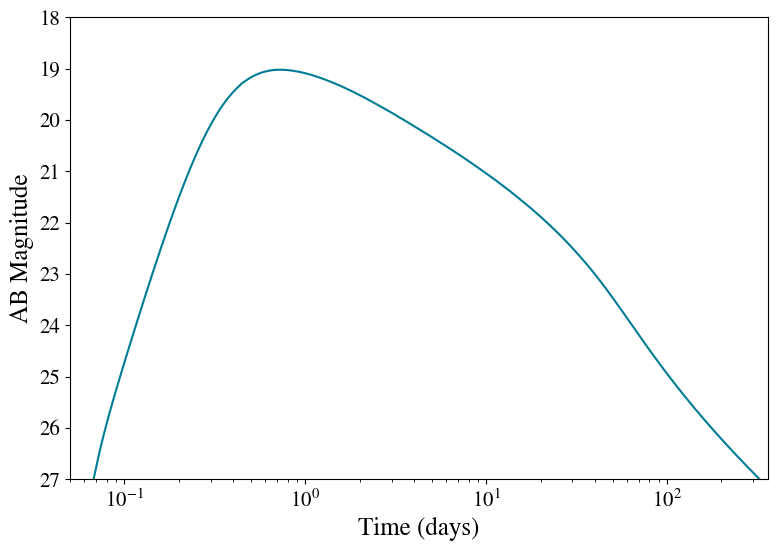

In [10]:
config = configs_oa[4]['config']

t = np.geomspace(1.0e3, 3.0e7, 300)   # time in seconds
nu = np.empty(t.shape)   
nu[:] = 5.0e14   # calculate flux in optical (r-band : wavelength = 600 nm)

Fnu = grb.fluxDensity(t, nu, **config)
mag = -2.5 * np.log10(Fnu * 1.0e-26) - 48.6

plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(9,6))

plt.plot(t*grb.sec2day, mag, color='#007c95')

plt.xlabel('Time (days)', fontsize=18)
plt.ylabel('AB Magnitude', fontsize=18)
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlim(0.05, 360)
plt.ylim(27, 18)

## Simulate its observation

In [11]:
baseline_db = get_baseline()
print(baseline_db)

conn = sqlite3.connect(baseline_db)

df = pd.read_sql('select * from observations;', conn)

conn.close()

path_rubin_sim_data = '/home/masson/rubin_sim_data'
fdir = os.path.join(path_rubin_sim_data, 'throughputs', 'baseline')

# Read the throughput curves
filterlist = ['u', 'g', 'r', 'i', 'z', 'y']
filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'y': 'm'}

lsst = {}
for f in filterlist:
    lsst[f] = Bandpass()
    lsst[f].readThroughput(os.path.join(fdir, f'total_{f}.dat'))

/home/masson/rubin_sim_data/sim_baseline/baseline_v2.1_10yrs.db


In [15]:
# dictionary containing all the GRB information
LC = {'config': {},  # Dictionary P
      'grb_time': 0,  # GRB observation date
      'grb_coord': 0,  # GRB ra/dec coordinates
      'time': [],  # Time of each detection
      'mags': [],  # Magnitude of the detection
      'filt': [],  # Filter used at the moment of the detection
      'mags_lim': [],  # Limiting magnitude of the detection at the observation time
      'mags_err': []}  # Error on the magnitude


# Time in mjd and ra/dec coordinates of the GRB (chosen randomly)
grb_time, grb_coord = time_coord()

# Observe t_before days before and t_after days after
t_before = TimeDelta(20, format='jd')
t_after = TimeDelta(365, format='jd')
obs_start = grb_time - t_before
obs_end = grb_time + t_after

# Get time span
df_time = df[(df['observationStartMJD'] > obs_start.mjd) & (df['observationStartMJD'] < obs_end.mjd)]

# Angular separation with SkyCoord.separation
# Rubin FOV is 47 square degree for a 3.5-degree diameter, hence 1.7 deg separation radius.
df_time['Separation'] = SkyCoord(df_time['fieldRA'], df_time['fieldDec'], unit="deg").separation(grb_coord).degree
df_sky = df_time[df_time['Separation'] < 1.7]

time_bins = grb_obs_duration(df_sky, grb_time)

obs_list = df_obs(config, df_sky, time_bins, lsst)

y_mags = []  # magnitude with extinction

# Sometimes, the afterglow is not observed
if len(obs_list) == 0:
    print('No observation for this orphan afterglow')

else:
    obs_df = pd.concat(obs_list)

    obs_df['observationId'] = df_sky['observationId']

    x_times, y_mags_without_ext, z_colors, mags_lim, mags_err = real_obs(obs_df, df_sky, time_bins, grb_time, lsst)

    LC['mags'] = np.array(y_mags_without_ext)
    LC['config'] = config
    LC['grb_time'] = grb_time.isot
    LC['grb_coord'] = grb_coord.to_string('hmsdms')
    LC['time'] = np.array(x_times)
    LC['filt'] = np.array(z_colors)
    LC['mags_lim'] = np.array(mags_lim)
    LC['mags_err'] = np.array(mags_err)[:, 0, 0]

## Plot

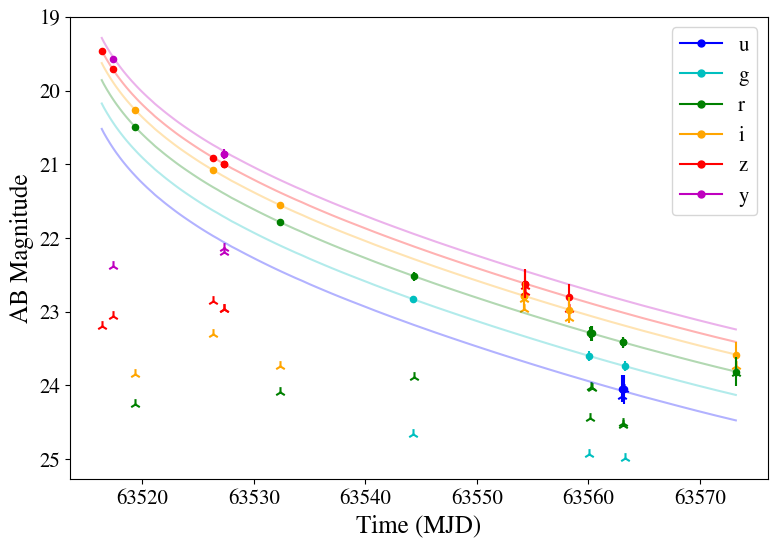

In [16]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(9,6))

filterlist = ['u', 'g', 'r', 'i', 'z', 'y']
filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'y': 'm'}
all_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 298760145396604.1]

x_times = np.array(LC['time'])
z_colors = LC['filt']
y_mags = np.array(LC['mags'])
mags_lim = np.array(LC['mags_lim'])
mags_err = LC['mags_err']
grb_time = Time(LC['grb_time']).mjd

for nu in all_nu:
    
    t_min = np.min(x_times[y_mags<mags_lim])
    t_max = np.max(x_times[y_mags<mags_lim])
    t = np.geomspace(t_min-grb_time, t_max-grb_time, num=100)
    
    mag = -2.5 * np.log10(grb.fluxDensity(t*grb.day2sec, nu, **config)*1.0e-26) - 48.6
    plt.plot(t+grb_time, mag, color=filtercolors[filterlist[all_nu.index(nu)]], alpha=0.3)

# plot pseudo observed light curve
for x, y, z, m, e in zip(x_times, y_mags, z_colors, mags_lim, mags_err):
    if y < m:
        plt.scatter(x, y, c=z, s=20)
        plt.errorbar(x, y, e, c=z, capsize=0)
        plt.scatter(x, m, c=z, marker='2', s=60)

plt.gca().invert_yaxis()
plt.xlabel('Time (MJD)', fontsize=18)
plt.ylabel('AB Magnitude', fontsize=18)

legend_elements_2 = list()

for filt in filterlist:
    fcolor = filtercolors[filt]
    legend_elements_2.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                                    markerfacecolor=fcolor, markersize=5))
plt.legend(handles=legend_elements_2)

plt.show()